# Example 002: Extrapolation of simulation data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import iddefix
from scipy.constants import c

## Simulation data example

This example features CST simulated wakefield data of the "Accelerator Cavity" introductory example.

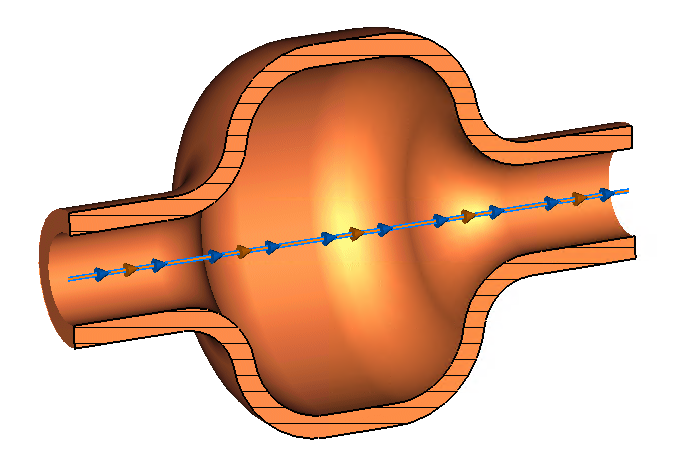

## Fitting on fully decayed wakefield

### Import data

In [2]:
# Importing impedance data
data_fully_decayed = np.loadtxt(
    "data/002_impedance_acceleratorCavity_fully_decayed.txt",
    comments="#",
    delimiter="\t",
)

# Extracting frequency and impedance

frequency = data_fully_decayed[:, 0] * 1e9  # Convert to GHz
real_impedance = data_fully_decayed[:, 1]
imag_impedance = data_fully_decayed[:, 2]

impedance_fd = real_impedance + 1j * imag_impedance

Visually inspecting the impedance

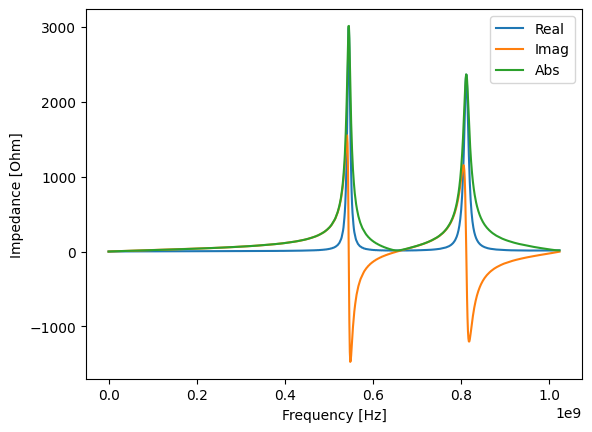

In [3]:
plt.plot(frequency, impedance_fd.real, label="Real")
plt.plot(frequency, impedance_fd.imag, label="Imag")
plt.plot(frequency, np.abs(impedance_fd), label="Abs")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Impedance [Ohm]")
plt.legend()

### Fitting resonators with IDDEFIX on the absolute magnitude of the 3 resonator impdance spectrum

In [4]:
# Bounds on resonators parameters
""" In this example, we will use the SmartBoundDetermination class to determine the bounds on the resonators parameters. 
By using SmartBoundDetermination ther is no need to specify the bounds manually."""

SBD_parameterBound = iddefix.SmartBoundDetermination(
    frequency, np.abs(impedance_fd), minimum_peak_height=1000
)

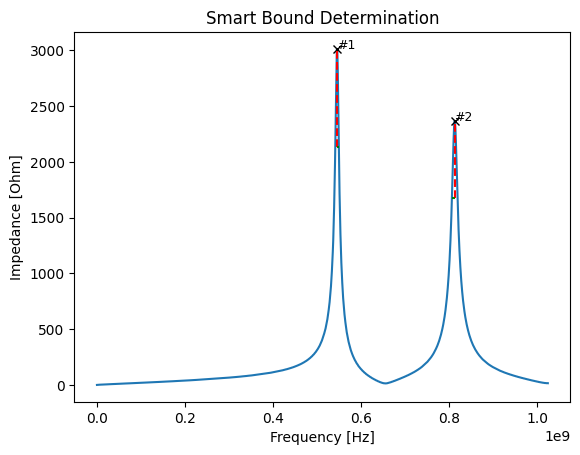

In [5]:
SBD_parameterBound.inspect()

#### Optional: pick resonances interactively
In Jupyter, enable an interactive Matplotlib backend (for example, `%matplotlib widget` or `ipympl`) before running the next cell. Set the flag to `True`, zoom or pan to inspect the spectrum, turn on **Pick**, right-click each mode, then press **Done**. This is optional; the automatic bounds above remain the default for the fitting example.

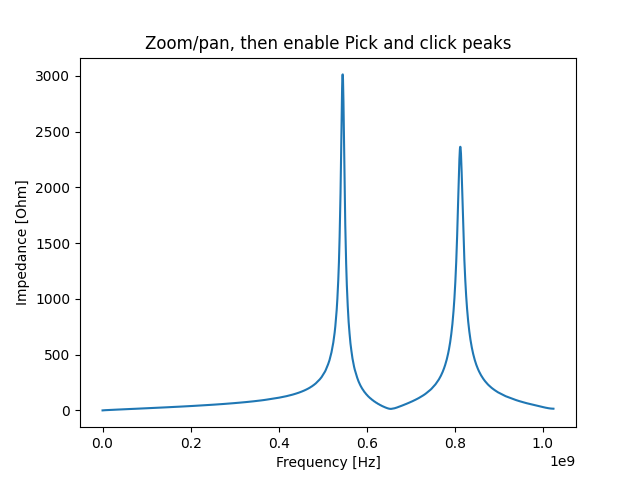

In [9]:
%matplotlib ipympl

manual_bounds = iddefix.SmartBoundDetermination(
    frequency,
    np.abs(impedance_fd),
    minimum_peak_height=1000,
    samples=2000,
    q_side="left",
    interactive=True,
)

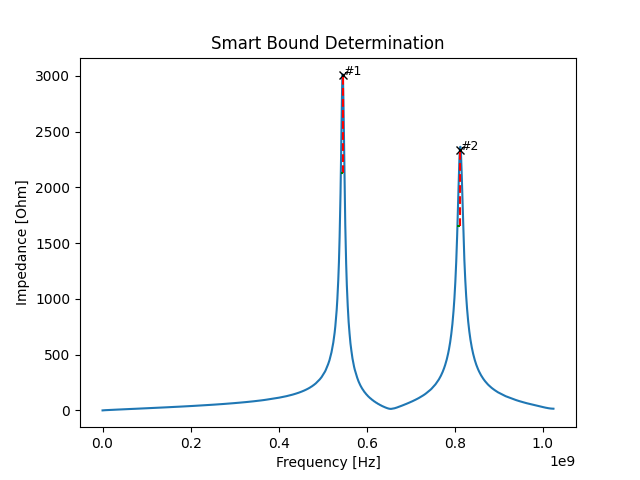

In [10]:
manual_bounds.inspect()

#### Running IDDEFIX DE
Running the DE algorithm with IDDEFIX and chosen parameters.

In [9]:
%%time
DE_model_fd = iddefix.EvolutionaryAlgorithm(
    frequency,
    impedance_fd,
    N_resonators=N_resonators,
    parameterBounds=SBD_parameterBound.find(),
    plane="longitudinal",
    objectiveFunction=iddefix.ObjectiveFunctions.sumOfSquaredError,
)

DE_model_fd.run_differential_evolution(
    maxiter=30000, popsize=30, tol=0.01, mutation=(0.4, 1.0), crossover_rate=0.7
)
print(DE_model_fd.warning)

[!] Using the fully decayed resonator formalism for impedance


Differential Evolution:   0%|          | 101/30000 [00:01<09:31, 52.32gen/s, conv=101.2 %]




----------------------------------------------------------------------------
Resonator |   Rs [Ohm/m or Ohm]    |        Q         |       fres [Hz]        
----------------------------------------------------------------------------
    1     |   3.02e+03 ± 1.2e+01   |   69.68 ± 0.38   |   5.45e+08 ± 1.5e+04   
    2     |   2.38e+03 ± 9.1e+00   |   65.22 ± 0.36   |   8.12e+08 ± 2.4e+04   
----------------------------------------------------------------------------
callback function requested stop early
CPU times: user 1.95 s, sys: 559 ms, total: 2.51 s
Wall time: 1.98 s


#### Minimization step
To further refine the solution obtained by the DE algorithm, a second optimization step is applied using the Nelder-Mead minimization algorithm.

In [10]:
DE_model_fd.run_minimization_algorithm()

Method for minimization : Nelder-Mead


----------------------------------------------------------------------------
Resonator |   Rs [Ohm/m or Ohm]    |        Q         |       fres [Hz]        
----------------------------------------------------------------------------
    1     |   3.03e+03 ± 1.2e+01   |   69.88 ± 0.38   |   5.45e+08 ± 1.5e+04   
    2     |   2.36e+03 ± 9.1e+00   |   64.55 ± 0.35   |   8.12e+08 ± 2.4e+04   
----------------------------------------------------------------------------


### Load and edit a resonator table
The printed parameters can be copied back into a model. Uncertainties are optional; missing ones default to zero. This separate model demonstrates adding and removing modes without changing `DE_model_fd` or the plots below. Resonator numbers in `remove_resonator()` start at 1.

In [11]:
loaded_model = iddefix.EvolutionaryAlgorithm(
    frequency,
    impedance_fd,
    N_resonators=2,
    parameterBounds=SBD_parameterBound.parameterBounds,
)

# Table can be copied direclty from model.display_resonator_parameters()
# or built by hand with or withou header

loaded_model.load_resonator_parameters(
    """
    Resonator | Rs [Ohm] | Q | fres [Hz]
    1 | 3.04e3 | 69.97 | 5.453e8
    2 | 2.37e3 | 64.96 | 8.123e8
    """
)
loaded_model.add_resonator(Rs=100.0, Q=10.0, fres=1.2e9, uncertainty=[10.0, 1.0, 1e7])
loaded_model.remove_resonator(1)
loaded_model.display_resonator_parameters()

[!] Objective function set to default                     `iddefix.objectiveFunctions.sumOfSquaredError`
[!] Using the fully decayed resonator formalism for impedance
[*] Displaying parameters after minimization


----------------------------------------------------------------------------
Resonator |   Rs [Ohm/m or Ohm]    |        Q         |       fres [Hz]        
----------------------------------------------------------------------------
    1     |   2.37e+03 ± 0.0e+00   |   64.96 ± 0.00   |   8.12e+08 ± 0.0e+00   
    2     |   1.00e+02 ± 1.0e+01   |   10.00 ± 1.00   |   1.20e+09 ± 1.0e+07   
----------------------------------------------------------------------------


### Assesing the fitting visually

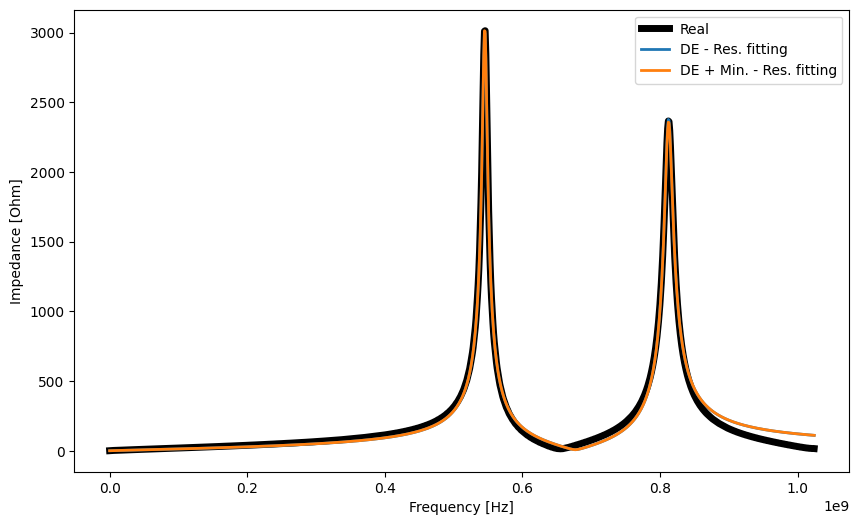

In [12]:
plt.figure(figsize=(10, 6))
result_DE = np.abs(DE_model_fd.get_impedance(use_minimization=False))
result_DE_MIN = np.abs(DE_model_fd.get_impedance())

plt.plot(frequency, np.abs(impedance_fd), lw=5, label="Real", color="black")
plt.plot(frequency, result_DE, lw=2, label="DE - Res. fitting")
plt.plot(frequency, result_DE_MIN, lw=2, label="DE + Min. - Res. fitting")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Impedance [Ohm]")
plt.legend()

## Fitting on partially decayed wakefield

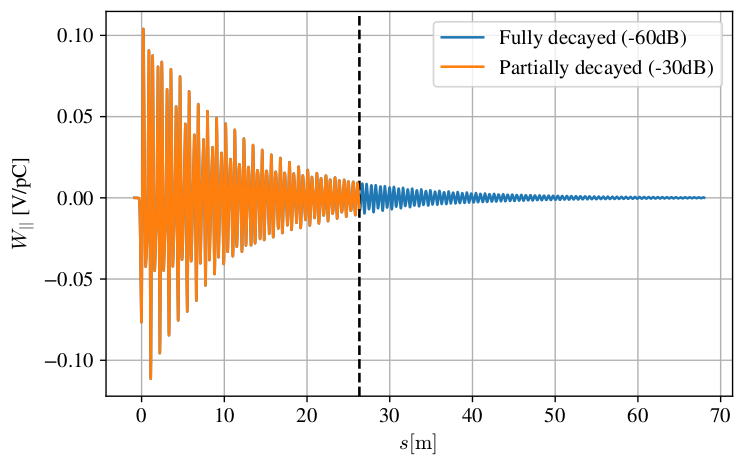

### Import data

In [11]:
# Importing impedance data
data_partially_decayed = np.loadtxt(
    "data/002_impedance_acceleratorCavity_partially_decayed.txt",
    comments="#",
    delimiter="\t",
)

# Extracting frequency and impedance

frequency = data_partially_decayed[:, 0] * 1e9  # Convert to GHz
real_impedance = data_partially_decayed[:, 1]
imag_impedance = data_partially_decayed[:, 2]

impedance_pd = real_impedance + 1j * imag_impedance

Visually inspecting the impedance

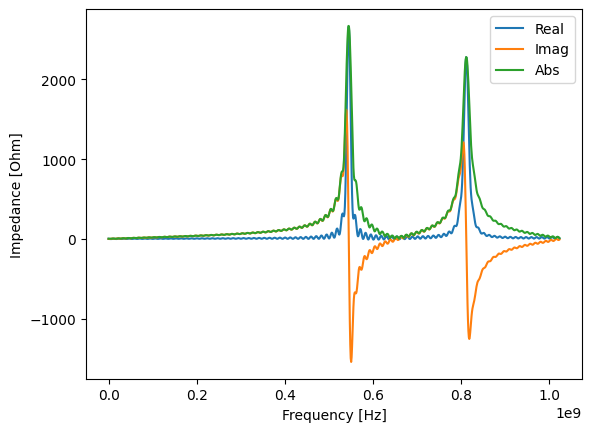

In [15]:
plt.figure()
plt.plot(frequency, impedance_pd.real, label="Real")
plt.plot(frequency, impedance_pd.imag, label="Imag")
plt.plot(frequency, np.abs(impedance_pd), label="Abs")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Impedance [Ohm]")
plt.legend()

### Fitting resonators with IDDEFIX

In [16]:
# Setting amount of resonators to fit

N_resonators = 2

# Bounds on resonators parameters
""" Bounds have this format [(Rs_min, Rs_max), (Q_min, Q_max), (fres_min, fres_max)].
ParameterBounds allows us to manually add a resonator with desired parameters """

bounds = [
    (1e3, 1e4),
    (1, 1e3),
    (0.4e9, 0.9e9),
]  # Bounds have this format [(Rs_min, Rs_max), (Q_min, Q_max), (fres_min, fres_max)].
parameterBounds = N_resonators * bounds

#### Running IDDEFIX DE
Running the DE algorithm with IDDEFIX and chosen parameters.

In [17]:
%%time
DE_model_pd = iddefix.EvolutionaryAlgorithm(
    frequency,
    impedance_pd,
    N_resonators=N_resonators,
    parameterBounds=parameterBounds,
    plane="longitudinal",
    wake_length=25.4,
    objectiveFunction=iddefix.ObjectiveFunctions.sumOfSquaredError,
)

DE_model_pd.run_differential_evolution(
    maxiter=30000, popsize=30, tol=0.01, mutation=(0.4, 1.0), crossover_rate=0.7
)
print(DE_model_pd.warning)

[!] Using the partially decayed resonator formalism for impedance


Differential Evolution:   1%|          | 295/30000 [00:05<09:40, 51.19gen/s, conv=107.2 %]




----------------------------------------------------------------------------
Resonator |   Rs [Ohm/m or Ohm]    |        Q         |       fres [Hz]        
----------------------------------------------------------------------------
    1     |   2.37e+03 ± 1.3e+01   |   65.18 ± 0.52   |   8.12e+08 ± 3.4e+04   
    2     |   3.04e+03 ± 1.9e+01   |   71.95 ± 0.66   |   5.45e+08 ± 2.3e+04   
----------------------------------------------------------------------------
callback function requested stop early
CPU times: user 5.36 s, sys: 1.56 s, total: 6.92 s
Wall time: 5.8 s


#### Minimization step

In [18]:
DE_model_pd.run_minimization_algorithm()

Method for minimization : Nelder-Mead


----------------------------------------------------------------------------
Resonator |   Rs [Ohm/m or Ohm]    |        Q         |       fres [Hz]        
----------------------------------------------------------------------------
    1     |   2.36e+03 ± 1.3e+01   |   64.98 ± 0.51   |   8.12e+08 ± 3.4e+04   
    2     |   3.05e+03 ± 1.9e+01   |   71.79 ± 0.65   |   5.45e+08 ± 2.3e+04   
----------------------------------------------------------------------------


### Assesing the fitting visually

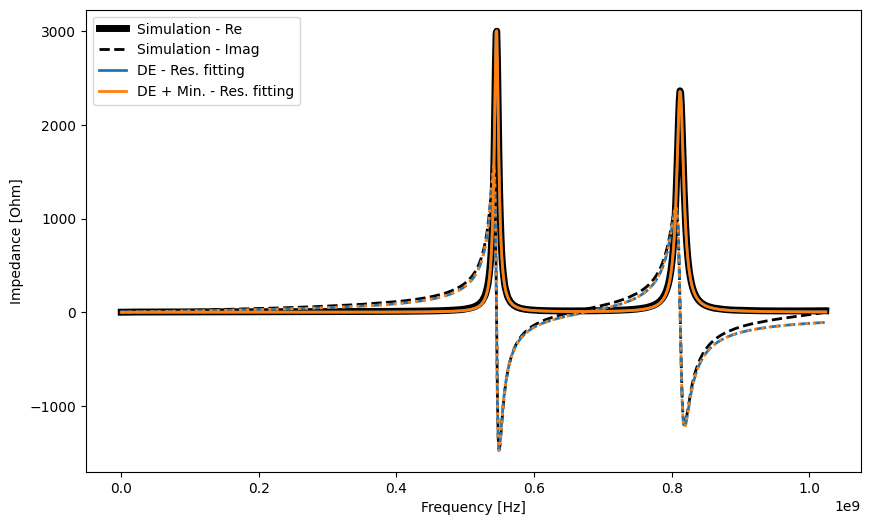

In [19]:
plt.figure(figsize=(10, 6))
result_DE = DE_model_pd.get_impedance(use_minimization=False)
result_DE_MIN = DE_model_pd.get_impedance()

plt.plot(frequency, np.real(impedance_fd), lw=5, label="Simulation - Re", color="black")
plt.plot(
    frequency,
    np.imag(impedance_fd),
    lw=2,
    ls="--",
    label="Simulation - Imag",
    color="black",
)
plt.plot(
    frequency, np.real(result_DE), lw=2, label="DE - Res. fitting", color="tab:blue"
)
plt.plot(frequency, np.imag(result_DE), lw=2, ls="--", color="tab:blue")
plt.plot(
    frequency,
    np.real(result_DE_MIN),
    lw=2,
    label="DE + Min. - Res. fitting",
    color="tab:orange",
)
plt.plot(frequency, np.imag(result_DE_MIN), lw=2, ls=":", color="tab:orange")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Impedance [Ohm]")
plt.legend()

Having fitted the resonators, we are also able to produce the wake function for any given wakelength:

Text(0, 0.5, 'Transverse wake function [V/pC]')

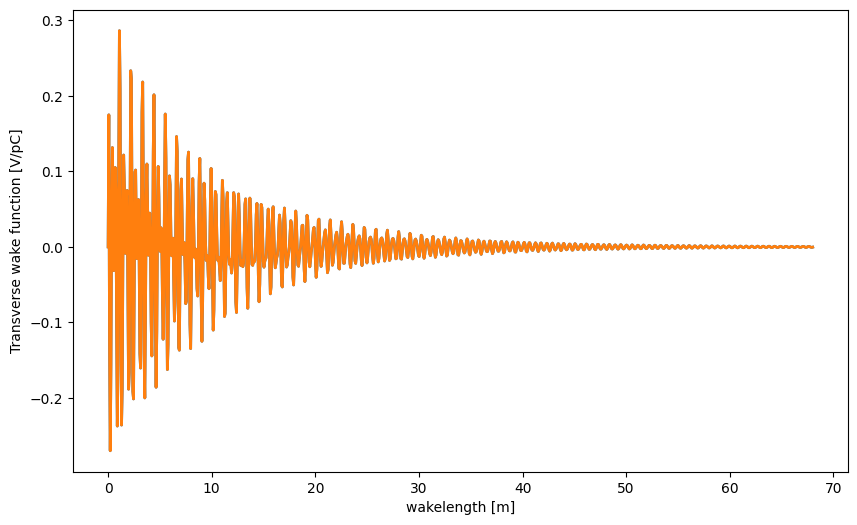

In [20]:
plt.figure(figsize=(10, 6))

timeframe = np.linspace(0, 68, 1000) / c

# From the formulas in resonatorFormalism.py
wake_function = (
    iddefix.Wakes.n_Resonator_longitudinal_wake(
        timeframe, DE_model_pd.minimizationParameters
    )
    / 1e12
)

# Or from the DE class itself:
wake_function_bis = DE_model_pd.get_wake(timeframe) / 1e12

plt.plot(timeframe * c, wake_function, lw=2, label="DE - Res. fitting")
plt.plot(
    timeframe * c,
    wake_function_bis,
    lw=2,
)
plt.xlabel("wakelength [m]")
plt.ylabel("Transverse wake function [V/pC]")